<a href="https://colab.research.google.com/github/juanrizo22/eye_disease_classification/blob/main/model%202/juanes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import kagglehub, os, cv2, numpy as np
import matplotlib.pyplot as plt

base_path = kagglehub.dataset_download("gunavenkatdoddi/eye-diseases-classification")
print(f"Descargado en: {base_path}")
base_path_real = os.path.join(base_path, "dataset") #Existia un archivo intermedio
print(f"Estructura: {base_path_real}")

for clase in os.listdir(base_path_real): #['glaucoma', 'normal', 'diabetic_retinopathy', 'cataract']
    n = len(os.listdir(os.path.join(base_path_real, clase))) # dataset/glaucoma --> [im1,im2....]-->len --> 1007 imagenes
    print(f"{clase}: {n} imágenes")

Using Colab cache for faster access to the 'eye-diseases-classification' dataset.
Descargado en: /kaggle/input/eye-diseases-classification
Estructura: /kaggle/input/eye-diseases-classification/dataset
glaucoma: 1007 imágenes
normal: 1074 imágenes
diabetic_retinopathy: 1098 imágenes
cataract: 1038 imágenes


In [24]:
os.listdir(base_path_real)

['glaucoma', 'normal', 'diabetic_retinopathy', 'cataract']

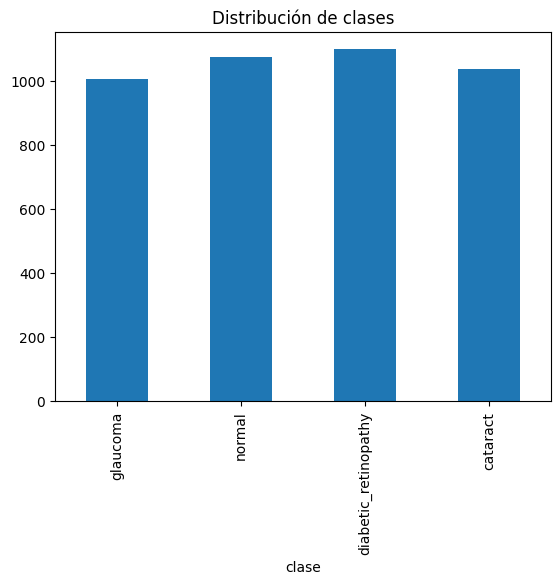

                  clase  n_imagenes
0              glaucoma        1007
1                normal        1074
2  diabetic_retinopathy        1098
3              cataract        1038


In [25]:
import pandas as pd

conteos = {c: len(os.listdir(os.path.join(base_path_real, c))) for c in os.listdir(base_path_real)} # dic comprehension {'glaucoma':1007....}
df_conteo = pd.DataFrame(list(conteos.items()), columns=['clase', 'n_imagenes']) #se crea el dataframe con el diccionario anterior, las columnas son clase y cantidad
df_conteo.plot(kind='bar', x='clase', y='n_imagenes', legend=False)
plt.title('Distribución de clases')
plt.show()
print(df_conteo)

(512, 512, 3)


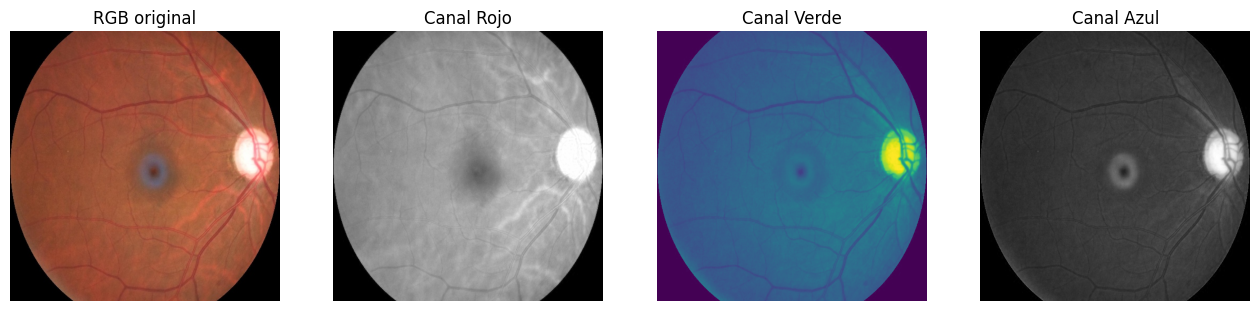

In [26]:
clase_ejemplo = os.listdir(base_path_real)[0] #[glaucoma]
carpeta = os.path.join(base_path_real, clase_ejemplo) #/dataset/glaucoma/
img_path = os.path.join(carpeta, os.listdir(carpeta)[0]) #dataset/glaucoma/im1
img = cv2.imread(img_path) #arreglo de numpy
print(img.shape)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
fig, axs = plt.subplots(1, 4, figsize=(16,4))
axs[0].imshow(img); axs[0].set_title('RGB original')
axs[1].imshow(img[:,:,0], cmap='gray'); axs[1].set_title('Canal Rojo')
axs[2].imshow(img[:,:,1]); axs[2].set_title('Canal Verde')
axs[3].imshow(img[:,:,2], cmap='gray'); axs[3].set_title('Canal Azul')
for ax in axs: ax.axis('off')
plt.show()

In [27]:
resoluciones = [] #acá vamos a almacenar el tamaño de los pixeles ancho x alto
for clase in os.listdir(base_path_real):
    carpeta = os.path.join(base_path_real, clase)
    for archivo in os.listdir(carpeta)[:50]:  # muestra de 50 por clase
        img = cv2.imread(os.path.join(carpeta, archivo))
        resoluciones.append(img.shape[:2]) #solo ancho y alto [(512,512), (512,512)...]

resoluciones = np.array(resoluciones)
print(f"Ancho: min={resoluciones[:,1].min()} max={resoluciones[:,1].max()} promedio={resoluciones[:,1].mean():.0f}")
print(f"Alto:  min={resoluciones[:,0].min()} max={resoluciones[:,0].max()} promedio={resoluciones[:,0].mean():.0f}")

Ancho: min=256 max=2592 promedio=549
Alto:  min=256 max=1728 promedio=499


De una muestra de 50 imagenes por clase encontramos resoluciones diferentes, esto para el modelo es ineficiente por lo que buscamos la manera de estandarizarlo


In [28]:
import hashlib

hashes, duplicados = {}, []
for clase in os.listdir(base_path_real):
    carpeta = os.path.join(base_path_real, clase)
    for archivo in os.listdir(carpeta):
        ruta = os.path.join(carpeta, archivo)
        with open(ruta, 'rb') as f:
            h = hashlib.md5(f.read()).hexdigest()
        if h in hashes:
            duplicados.append(ruta)
        else:
            hashes[h] = ruta
print(f"Duplicados encontrados: {len(duplicados)}")

Duplicados encontrados: 2


In [29]:
def preprocesar_imagen(img_path, size=(224,224)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)

    # Corrección de iluminación (resta de un blur gaussiano, como en [1])
    blur = cv2.GaussianBlur(img, (0,0), sigmaX=10)
    img_corregida = cv2.addWeighted(img, 4, blur, -4, 128)

    # CLAHE sobre el canal verde (como en [3])
    lab = cv2.cvtColor(img_corregida, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_final = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

    return img_final / 255.0  # normalizado a [0,1]

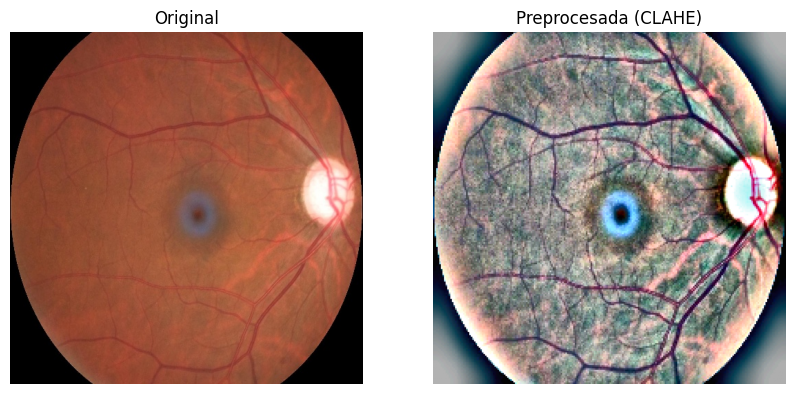

In [30]:
img_original = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
img_procesada = preprocesar_imagen(img_path)

fig, axs = plt.subplots(1,2, figsize=(10,5))
axs[0].imshow(img_original); axs[0].set_title('Original')
axs[1].imshow(img_procesada); axs[1].set_title('Preprocesada (CLAHE)')
for ax in axs: ax.axis('off')
plt.show()

In [31]:
pip install split-folders

In [32]:
import splitfolders
splitfolders.ratio(base_path_real, output="dataset_dividido", seed=42, ratio=(.7,.15,.15))

Copying files: 4217 files [00:18, 227.72 files/s]


In [39]:
train_ds = tf.keras.utils.image_dataset_from_directory('dataset_dividido/train', image_size=(224,224), batch_size=32)
val_ds = tf.keras.utils.image_dataset_from_directory('dataset_dividido/val', image_size=(224,224), batch_size=32)
test_ds = tf.keras.utils.image_dataset_from_directory('dataset_dividido/test', image_size=(224,224), batch_size=32, shuffle=False)

clases = train_ds.class_names  # guárdalo aquí, apenas se crea

# Ahora sí pueden encadenar transformaciones sin perder la referencia:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

Found 2949 files belonging to 4 classes.
Found 631 files belonging to 4 classes.
Found 637 files belonging to 4 classes.


In [33]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

In [34]:
from sklearn.utils.class_weight import compute_class_weight

clases_train = os.listdir(base_path_real)  # etiquetas de todo el set de entrenamiento
pesos = compute_class_weight('balanced', classes=np.unique(clases_train), y=clases_train)
class_weight = dict(enumerate(pesos))

In [35]:
print(os.listdir(base_path_real))

['glaucoma', 'normal', 'diabetic_retinopathy', 'cataract']


In [36]:
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB3
from tensorflow.keras import layers, models

def construir_modelo(base_arch, input_shape=(224,224,3), n_clases=4):
    base_model = base_arch(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False  # fase 1: solo entrenamos el head

    modelo = models.Sequential([
        data_augmentation,
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(n_clases, activation='softmax')
    ])
    modelo.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
    return modelo

modelo_b0 = construir_modelo(EfficientNetB0)
modelo_b3 = construir_modelo(EfficientNetB3)

In [37]:
def entrenar_dos_fases(modelo, train_ds, val_ds, class_weight=None, epochs_fase1=10, epochs_fase2=5):
    # Fase 1: base congelada
    historia1 = modelo.fit(train_ds, validation_data=val_ds, epochs=epochs_fase1, class_weight=class_weight)

    # Fase 2: fine-tuning (descongelar las últimas capas)
    modelo.layers[1].trainable = True  # el base_model
    for layer in modelo.layers[1].layers[:-20]:
        layer.trainable = False  # solo las últimas 20 capas se ajustan

    modelo.compile(optimizer=tf.keras.optimizers.Adam(1e-5),  # LR bajo para fine-tuning
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    historia2 = modelo.fit(train_ds, validation_data=val_ds, epochs=epochs_fase2, class_weight=class_weight)

    return historia1, historia2

20/20 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step

=== EfficientNetB0 ===
                      precision    recall  f1-score   support

            cataract       1.00      0.01      0.03       157
diabetic_retinopathy       0.00      0.00      0.00       166
            glaucoma       0.25      0.98      0.40       152
              normal       0.04      0.01      0.02       162

            accuracy                           0.24       637
           macro avg       0.32      0.25      0.11       637
        weighted avg       0.32      0.24      0.11       637

MCC: 0.0010


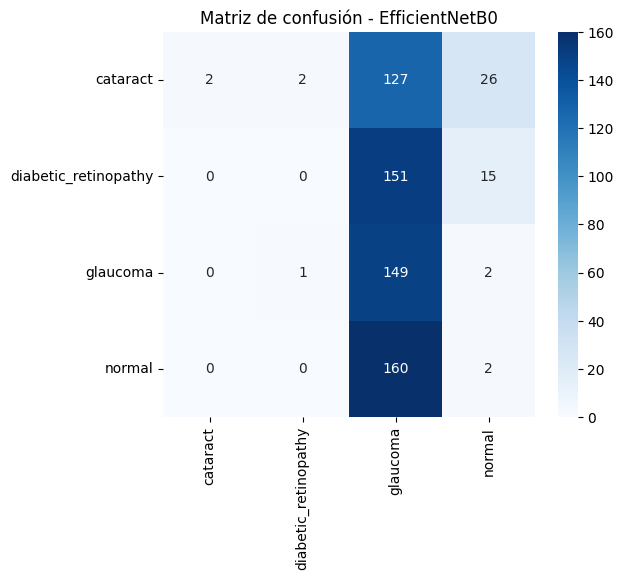

20/20 ━━━━━━━━━━━━━━━━━━━━ 104s 5s/step

=== EfficientNetB3 ===
                      precision    recall  f1-score   support

            cataract       0.21      0.10      0.13       157
diabetic_retinopathy       0.57      0.05      0.09       166
            glaucoma       0.35      0.12      0.18       152
              normal       0.30      0.91      0.45       162

            accuracy                           0.30       637
           macro avg       0.36      0.29      0.21       637
        weighted avg       0.36      0.30      0.21       637

MCC: 0.0852


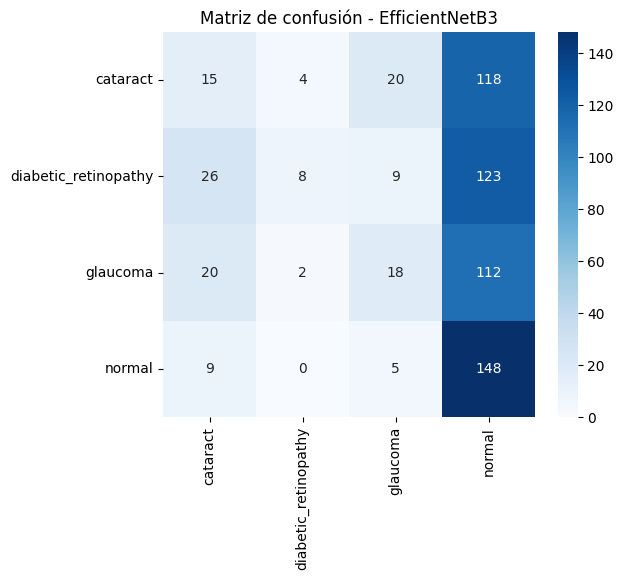

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef
import seaborn as sns

def evaluar_modelo(modelo, test_ds, nombre_modelo, clases):
    y_true = np.concatenate([y for x, y in test_ds], axis=0)
    y_pred = np.argmax(modelo.predict(test_ds), axis=1)

    print(f"\n=== {nombre_modelo} ===")
    print(classification_report(y_true, y_pred, target_names=clases))
    print(f"MCC: {matthews_corrcoef(y_true, y_pred):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=clases, yticklabels=clases, cmap='Blues')
    plt.title(f'Matriz de confusión - {nombre_modelo}')
    plt.savefig(f'confusion_{nombre_modelo}.png')
    plt.show()

    return y_true, y_pred

evaluar_modelo(modelo_b0, test_ds, "EfficientNetB0", clases)
evaluar_modelo(modelo_b3, test_ds, "EfficientNetB3", clases)
